In [5]:
import duckdb

con = duckdb.connect("ecommerce.duckdb")

In [7]:
con.sql("""
CREATE OR REPLACE TABLE olist_orders AS
SELECT *
FROM read_csv_auto('../data/raw/olist_orders_dataset.csv');
""")
con.sql("""
CREATE OR REPLACE TABLE olist_order_items AS
SELECT *
FROM read_csv_auto('../data/raw/olist_order_items_dataset.csv');
""")
con.sql("""
CREATE OR REPLACE TABLE olist_customers AS
SELECT *
FROM read_csv_auto('../data/raw/olist_customers_dataset.csv');
""")
con.sql("SHOW TABLES").df()

,name
0,olist_customers
1,olist_order_items
2,olist_orders


In [10]:
import duckdb
con = duckdb.connect("ecommerce.duckdb")

rfm_df = con.sql("""
WITH base AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        STRPTIME(
            o.order_purchase_timestamp,
            '%d/%m/%Y %H:%M'
        )::DATE AS order_date,
        SUM(oi.price + oi.freight_value) AS order_value
    FROM olist_orders o
    JOIN olist_order_items oi USING (order_id)
    JOIN olist_customers   c  USING (customer_id)
    WHERE o.order_status = 'delivered'
    GROUP BY 1, 2, 3
),
ref AS (
    SELECT MAX(order_date) AS ref_date FROM base
),
rfm_raw AS (
    SELECT
        customer_unique_id,
        DATEDIFF('day', MAX(order_date), (SELECT ref_date FROM ref)) AS recency,
        COUNT(DISTINCT order_id)                                      AS frequency,
        ROUND(SUM(order_value), 2)                                    AS monetary
    FROM base
    GROUP BY 1
),
rfm_scored AS (
    SELECT *,
        NTILE(5) OVER (ORDER BY recency   ASC)  AS r_score,
        NTILE(5) OVER (ORDER BY frequency DESC) AS f_score,
        NTILE(5) OVER (ORDER BY monetary  DESC) AS m_score
    FROM rfm_raw
),
rfm_segmented AS (
    SELECT *,
        CASE
            WHEN r_score >= 4 AND f_score >= 4                          THEN 'Champions'
            WHEN r_score >= 3 AND f_score >= 3                          THEN 'Loyal'
            WHEN r_score >= 4 AND f_score <= 2                          THEN 'Recent'
            WHEN r_score = 5  AND f_score = 1                           THEN 'New'
            WHEN r_score BETWEEN 2 AND 3 AND f_score >= 3               THEN 'At Risk'
            WHEN r_score <= 2 AND f_score >= 3                          THEN 'Cannot Lose'
            WHEN r_score BETWEEN 2 AND 3 AND f_score BETWEEN 1 AND 2    THEN 'Needs Attention'
            ELSE                                                              'Lost'
        END AS segment
    FROM rfm_scored
)
SELECT * FROM rfm_segmented ORDER BY monetary DESC;
""").df()


print("Shape:", rfm_df.shape)
print()
print("=== Segment distribution ===")
print(rfm_df['segment'].value_counts())
print()
print("=== RFM descriptive stats ===")
print(rfm_df[['recency','frequency','monetary']].describe().round(2))
print()
print("=== Top 5 rows ===")
print(rfm_df.head())

Shape: (93358, 8)

=== Segment distribution ===
segment
Loyal              26445
Lost               18672
Champions          17176
At Risk            12393
Recent             11789
Needs Attention     6883
Name: count, dtype: int64

=== RFM descriptive stats ===
        recency  frequency  monetary
count  93358.00   93358.00  93358.00
mean     237.48       1.03    165.17
std      152.60       0.21    226.29
min        0.00       1.00      9.59
25%      114.00       1.00     63.01
50%      218.00       1.00    107.78
75%      346.00       1.00    182.51
max      713.00      15.00  13664.08

=== Top 5 rows ===
                 customer_unique_id  recency  frequency  monetary  r_score  \
0  0a0a92112bd4c708ca5fde585afaa872      334          1  13664.08        4   
1  da122df9eeddfedc1dc1f5349a1a690c      515          2   7571.63        5   
2  763c8b1c9c68a0229c42c9fc6f662b93       45          1   7274.88        1   
3  dc4802a71eae9be1dd28f5d788ceb526      563          1   6929.31       

In [11]:
#kiểm tra frequency distribution thật
print("=== Frequency distribution ===")
print(rfm_df['frequency'].value_counts().sort_index())
print()
print("=== % khách chỉ mua 1 lần ===")
one_time = (rfm_df['frequency'] == 1).sum()
print(f"{one_time:,} / {len(rfm_df):,} = {one_time/len(rfm_df)*100:.1f}%")
print()
print("=== r_score vs f_score crosstab ===")
print(rfm_df.groupby(['r_score','f_score']).size().unstack(fill_value=0))

=== Frequency distribution ===
frequency
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

=== % khách chỉ mua 1 lần ===
90,557 / 93,358 = 97.0%

=== r_score vs f_score crosstab ===
f_score      1      2      3      4      5
r_score                                   
1        16494   2178      0      0      0
2          578   5701  10292   1537    564
3          604      0      3  17134    931
4          561    777    157      0  17176
5          435  10016   8220      0      0


In [12]:
#fixed pipeline với segment logic phù hợp Olist
rfm_fixed = con.sql("""
WITH base AS (
    SELECT
        c.customer_unique_id,
        o.order_id,
        STRPTIME(
            o.order_purchase_timestamp,
            '%d/%m/%Y %H:%M'
        )::DATE AS order_date,
        SUM(oi.price + oi.freight_value) AS order_value
    FROM olist_orders o
    JOIN olist_order_items oi USING (order_id)
    JOIN olist_customers   c  USING (customer_id)
    WHERE o.order_status = 'delivered'
    GROUP BY 1, 2, 3
),

ref AS (
    SELECT MAX(order_date) AS ref_date FROM base
),

rfm_raw AS (
    SELECT
        customer_unique_id,
        DATEDIFF('day', MAX(order_date), (SELECT ref_date FROM ref)) AS recency,
        COUNT(DISTINCT order_id)                                      AS frequency,
        ROUND(SUM(order_value), 2)                                    AS monetary
    FROM base
    GROUP BY 1
),

rfm_scored AS (
    SELECT *,
        NTILE(5) OVER (ORDER BY recency  ASC)  AS r_score,
        -- F: score trực tiếp từ raw value, không NTILE
        CASE
            WHEN frequency >= 5 THEN 5
            WHEN frequency = 4  THEN 4
            WHEN frequency = 3  THEN 3
            WHEN frequency = 2  THEN 2
            ELSE                     1
        END                                     AS f_score,
        NTILE(5) OVER (ORDER BY monetary DESC)  AS m_score
    FROM rfm_raw
),

rfm_segmented AS (
    SELECT *,
        CASE
            -- Repeat buyers (frequency >= 2) phân theo recency
            WHEN frequency >= 2 AND r_score >= 4  THEN 'Champions'
            WHEN frequency >= 2 AND r_score >= 2  THEN 'Loyal'
            WHEN frequency >= 2 AND r_score < 2   THEN 'At Risk'
            -- One-time buyers (frequency = 1) phân theo recency
            WHEN frequency = 1  AND r_score = 5   THEN 'New'
            WHEN frequency = 1  AND r_score >= 3  THEN 'Promising'
            WHEN frequency = 1  AND r_score = 2   THEN 'Needs Attention'
            ELSE                                       'Lost'
        END AS segment
    FROM rfm_scored
)

SELECT * FROM rfm_segmented ORDER BY monetary DESC;
""").df()

print("=== Fixed segment distribution ===")
print(rfm_fixed['segment'].value_counts())
print()
print("=== Monetary per segment ===")
print(rfm_fixed.groupby('segment')['monetary'].agg(['mean','median','sum']).round(2).sort_values('sum', ascending=False))

=== Fixed segment distribution ===
segment
Promising          36181
New                18234
Needs Attention    18091
Lost               18051
Loyal               1185
Champions            995
At Risk              621
Name: count, dtype: int64

=== Monetary per segment ===
                   mean  median         sum
segment                                    
Promising        157.59  104.54  5701760.10
Needs Attention  165.26  108.41  2989749.09
Lost             163.41  107.79  2949638.08
New              159.84  103.11  2914439.02
Loyal            311.96  227.54   369670.54
Champions        294.77  210.56   293297.09
At Risk          324.03  238.55   201219.83


In [14]:
import pandas as pd
# Verify recency cutoffs theo r_score
print("=== Recency range per r_score ===")
print(rfm_fixed.groupby('r_score')['recency'].agg(['min','max','median','count']))
print()

# Revenue concentration — Pareto check
total_rev = rfm_fixed['monetary'].sum()
seg_revenue = (rfm_fixed.groupby('segment')['monetary']
               .sum()
               .sort_values(ascending=False))
seg_revenue_pct = (seg_revenue / total_rev * 100).round(1)
seg_count_pct   = (rfm_fixed['segment'].value_counts() / len(rfm_fixed) * 100).round(1)

pareto = pd.DataFrame({
    'revenue_sum':  seg_revenue.round(0).astype(int),
    'revenue_pct':  seg_revenue_pct,
    'customer_pct': seg_count_pct
})
print("=== Pareto: revenue vs customer % ===")
print(pareto)
print()
print(f"Total portfolio revenue: ${total_rev:,.0f}")
print(f"Repeat buyers (freq>=2): {(rfm_fixed['frequency']>=2).sum():,} customers")
print(f"Repeat buyer revenue:    ${rfm_fixed[rfm_fixed['frequency']>=2]['monetary'].sum():,.0f}")

=== Recency range per r_score ===
         min  max  median  count
r_score                         
1          0   92    41.0  18672
2         92  177   134.0  18672
3        177  268   218.5  18672
4        268  382   312.0  18671
5        382  713   465.0  18671

=== Pareto: revenue vs customer % ===
                 revenue_sum  revenue_pct  customer_pct
segment                                                
At Risk               201220          1.3           0.7
Champions             293297          1.9           1.1
Lost                 2949638         19.1          19.3
Loyal                 369671          2.4           1.3
Needs Attention      2989749         19.4          19.4
New                  2914439         18.9          19.5
Promising            5701760         37.0          38.8

Total portfolio revenue: $15,419,774
Repeat buyers (freq>=2): 2,801 customers
Repeat buyer revenue:    $864,187


Exported: rfm_segments.csv — 93,358 rows


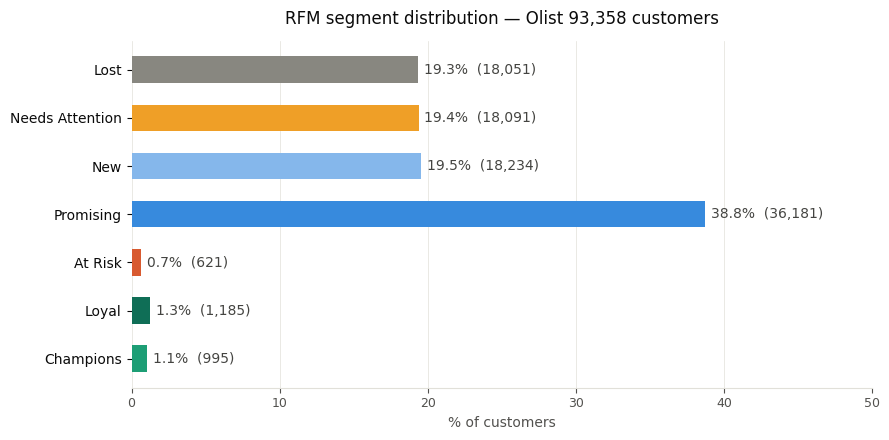

Saved: rfm_segment_distribution.png


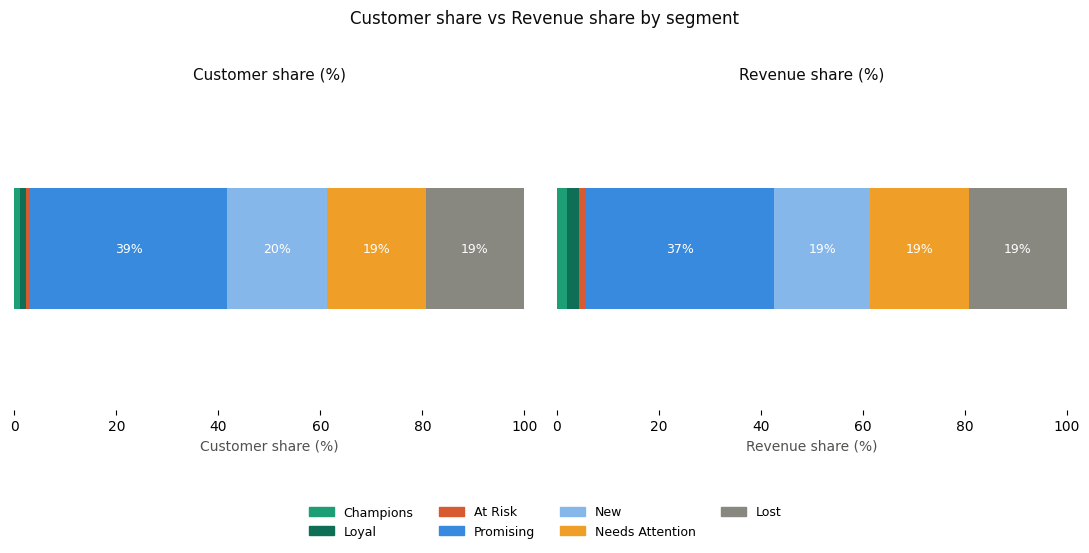

Saved: rfm_revenue_contribution.png


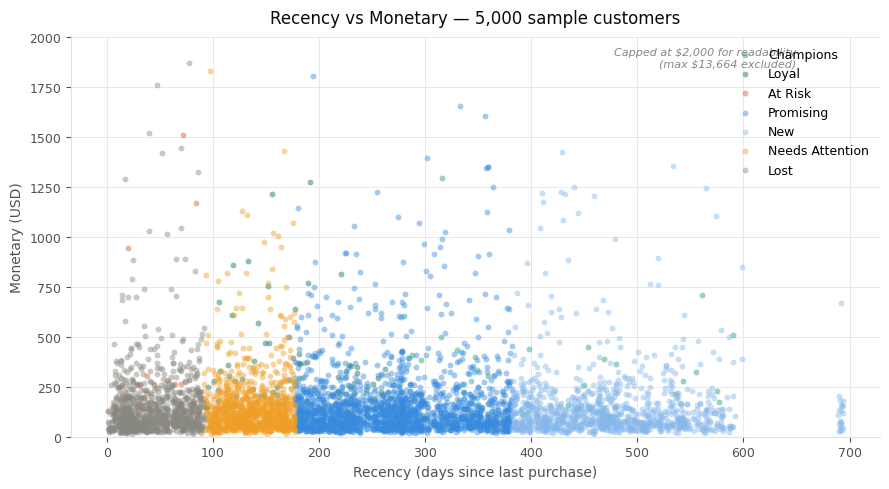

Saved: rfm_recency_monetary_scatter.png

=== Export summary ===
Total customers:      93,358
Total revenue:        $15,419,774
Repeat buyers:        2,801 (3.0%)
Repeat buyer revenue: $864,187
Avg monetary:         $165.17
Median recency:       218 days


In [15]:
#Export + Visualization
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

os.makedirs('../app', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# ── Export CSV ──────────────────────────────────────────────
rfm_fixed.to_csv('../app/rfm_segments.csv', index=False)
print(f"Exported: rfm_segments.csv — {rfm_fixed.shape[0]:,} rows")

# ── Palette ─────────────────────────────────────────────────
SEG_ORDER = ['Champions','Loyal','At Risk',
             'Promising','New','Needs Attention','Lost']
COLORS = {
    'Champions':       '#1D9E75',
    'Loyal':           '#0F6E56',
    'At Risk':         '#D85A30',
    'Promising':       '#378ADD',
    'New':             '#85B7EB',
    'Needs Attention': '#EF9F27',
    'Lost':            '#888780',
}

seg_stats = (rfm_fixed.groupby('segment')
             .agg(customers=('customer_unique_id','count'),
                  revenue=('monetary','sum'),
                  avg_monetary=('monetary','mean'),
                  avg_recency=('recency','mean'))
             .reindex(SEG_ORDER)
             .assign(revenue_pct=lambda d: d['revenue']/d['revenue'].sum()*100,
                     customer_pct=lambda d: d['customers']/d['customers'].sum()*100))

# ════════════════════════════════════════════════════════════
# Fig 1 — Segment distribution (horizontal bar)
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 4.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars = ax.barh(SEG_ORDER,
               seg_stats.loc[SEG_ORDER, 'customer_pct'],
               color=[COLORS[s] for s in SEG_ORDER],
               height=0.55, zorder=2)

for bar, seg in zip(bars, SEG_ORDER):
    w = bar.get_width()
    n = seg_stats.loc[seg, 'customers']
    ax.text(w + 0.4, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}%  ({n:,})',
            va='center', ha='left', fontsize=10, color='#444441')

ax.set_xlabel('% of customers', fontsize=10, color='#52514e')
ax.set_xlim(0, 50)
ax.set_title('RFM segment distribution — Olist 93,358 customers',
             fontsize=12, fontweight='normal', pad=12, color='#0b0b0b')
ax.tick_params(axis='y', labelsize=10, colors='#0b0b0b')
ax.tick_params(axis='x', labelsize=9,  colors='#52514e')
ax.spines[['top','right','left']].set_visible(False)
ax.spines['bottom'].set_color('#e1e0d9')
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('../reports/rfm_segment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rfm_segment_distribution.png")

# ════════════════════════════════════════════════════════════
# Fig 2 — Revenue contribution (stacked % bar — Pareto visual)
# ════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.patch.set_facecolor('white')

for ax, metric, title, col in zip(
        axes,
        ['customer_pct', 'revenue_pct'],
        ['Customer share (%)', 'Revenue share (%)'],
        ['customers', 'revenue']):
    ax.set_facecolor('white')
    vals = seg_stats.loc[SEG_ORDER, metric]
    colors = [COLORS[s] for s in SEG_ORDER]
    left = 0
    for val, color, seg in zip(vals, colors, SEG_ORDER):
        ax.barh(0, val, left=left, color=color, height=0.45)
        if val > 3:
            ax.text(left + val/2, 0,
                    f'{val:.0f}%', va='center', ha='center',
                    fontsize=9, color='white', fontweight='normal')
        left += val
    ax.set_xlim(0, 100)
    ax.set_ylim(-0.6, 0.6)
    ax.set_xlabel(title, fontsize=10, color='#52514e')
    ax.set_yticks([])
    ax.set_title(title, fontsize=11, fontweight='normal', color='#0b0b0b')
    ax.spines[['top','right','left','bottom']].set_visible(False)

patches = [mpatches.Patch(color=COLORS[s], label=s) for s in SEG_ORDER]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.18))
fig.suptitle('Customer share vs Revenue share by segment',
             fontsize=12, fontweight='normal', color='#0b0b0b', y=1.02)
plt.tight_layout()
plt.savefig('../reports/rfm_revenue_contribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rfm_revenue_contribution.png")

# ════════════════════════════════════════════════════════════
# Fig 3 — Recency × Monetary scatter (sample 5k, màu = segment)
# ════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

sample = rfm_fixed.sample(5000, random_state=42)

for seg in SEG_ORDER:
    d = sample[sample['segment'] == seg]
    ax.scatter(d['recency'], d['monetary'],
               c=COLORS[seg], label=seg,
               alpha=0.45, s=18, linewidths=0, zorder=2)

ax.set_xlabel('Recency (days since last purchase)', fontsize=10, color='#52514e')
ax.set_ylabel('Monetary (USD)', fontsize=10, color='#52514e')
ax.set_ylim(0, 2000)   # cap outlier $13k để scatter readable
ax.set_title('Recency vs Monetary — 5,000 sample customers',
             fontsize=12, fontweight='normal', color='#0b0b0b', pad=10)
ax.legend(fontsize=9, frameon=False, loc='upper right')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#e1e0d9')
ax.xaxis.grid(True, color='#e1e0d9', linewidth=0.5, zorder=1)
ax.yaxis.grid(True, color='#e1e0d9', linewidth=0.5, zorder=1)
ax.set_axisbelow(True)
ax.tick_params(colors='#52514e', labelsize=9)
ax.text(650, 1850,
        'Capped at $2,000 for readability\n(max $13,664 excluded)',
        ha='right', fontsize=8, color='#898781', style='italic')
plt.tight_layout()
plt.savefig('../reports/rfm_recency_monetary_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: rfm_recency_monetary_scatter.png")

# ── Summary ─────────────────────────────────────────────────
print()
print("=== Export summary ===")
print(f"Total customers:      {len(rfm_fixed):,}")
print(f"Total revenue:        ${rfm_fixed['monetary'].sum():,.0f}")
print(f"Repeat buyers:        {(rfm_fixed['frequency']>=2).sum():,} ({(rfm_fixed['frequency']>=2).mean()*100:.1f}%)")
print(f"Repeat buyer revenue: ${rfm_fixed[rfm_fixed['frequency']>=2]['monetary'].sum():,.0f}")
print(f"Avg monetary:         ${rfm_fixed['monetary'].mean():.2f}")
print(f"Median recency:       {rfm_fixed['recency'].median():.0f} days")